评估企业贷款违约风险
#本项目基于美国小企业管理局（SBA）的贷款数据，建立分类模型预测企业是否会违约（贷款无法偿还）。  
#我们将采用传统机器学习方法和AutoML框架（LightAutoML）分别建模，并比较两者的性能。

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from category_encoders.wrapper import NestedCVWrapper
from category_encoders import TargetEncoder
import category_encoders as ce


!pip install lightautoml -q
from lightautoml.automl.presets.tabular_presets import TabularAutoML
from lightautoml.tasks import Task

You should consider upgrading via the 'c:\users\user\appdata\local\programs\python\python38\python.exe -m pip install --upgrade pip' command.


加载数据

In [2]:
df = pd.read_csv('SBAnational.csv', encoding='latin-1', low_memory=False)
print("原始数据形状:", df.shape)

# 创建目标变量
df['default'] = (df['MIS_Status'] == 'CHGOFF').astype(int)
print("违约率:", df['default'].mean())

原始数据形状: (899164, 27)
违约率: 0.17522721105382333


数据预处理
选取合适的特征

In [16]:
# 安全特征列表（仅贷款申请时可获得的信息）
safe_features = [
    'NoEmp', 'NewExist', 'CreateJob', 'RetainedJob',
    'FranchiseCode', 'UrbanRural', 'RevLineCr', 'LowDoc',
    'GrAppv', 'SBA_Appv', 'ApprovalFY'
]

# 从 ApprovalDate 提取年份和月份（不包含未来信息）
if 'ApprovalDate' in df.columns:
    df['ApprovalDate'] = pd.to_datetime(df['ApprovalDate'], format='%d-%b-%y', errors='coerce')
    df['ApprovalYear'] = df['ApprovalDate'].dt.year
    df['ApprovalMonth'] = df['ApprovalDate'].dt.month
    safe_features += ['ApprovalYear', 'ApprovalMonth']

# 确保所有特征列存在
safe_features = [f for f in safe_features if f in df.columns]

# 目标列
target_col = 'default'

print("使用的特征:", safe_features)
print("特征数量:", len(safe_features))


使用的特征: ['NoEmp', 'NewExist', 'CreateJob', 'RetainedJob', 'FranchiseCode', 'UrbanRural', 'RevLineCr', 'LowDoc', 'GrAppv', 'SBA_Appv', 'ApprovalFY', 'ApprovalYear', 'ApprovalMonth']
特征数量: 13


划分训练集和测试集

In [17]:
X = df[safe_features].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")

训练集大小: (719331, 13), 测试集大小: (179833, 13)


In [ ]:
缺失值处理

In [18]:
# 识别数值列和类别列
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

# 数值列：用中位数填充（仅用训练集拟合）
num_imputer = SimpleImputer(strategy='median')
X_train[num_features] = num_imputer.fit_transform(X_train[num_features])
X_test[num_features] = num_imputer.transform(X_test[num_features])

# 类别列：用固定字符串填充（安全）
for col in cat_features:
    X_train[col] = X_train[col].astype(str).fillna('missing')
    X_test[col] = X_test[col].astype(str).fillna('missing')

print("缺失值处理完成")

缺失值处理完成


特征编码
根据要求，使用 category_encoders 库中的两种编码方式：  
**WOE (Weight of Evidence)**：适用于逻辑回归，能自然处理分类变量并给出可解释性  
 **Target Encoding**（目标编码）：另一种常见的监督编码，这里我们使用 `TargetEncoder` 作为第二种方案  
#注意：WOE 编码要求目标变量为二分类且无缺失，我们将目标变量传入编码器。

In [35]:
# 对类别特征进行目标编码（使用交叉验证防止过拟合）
# 创建一个基础的 TargetEncoder
base_encoder = TargetEncoder(cols=cat_features, smoothing=10)

# 用 NestedCVWrapper 包装它，并设置 cv 折数
target_encoder = NestedCVWrapper(base_encoder, cv=5)
X_train_encoded = target_encoder.fit_transform(X_train, y_train)
X_test_encoded = target_encoder.transform(X_test)

# 对 WOE 编码（用于逻辑回归）
woe_encoder = ce.WOEEncoder(cols=cat_features, random_state=42)
X_train_woe = woe_encoder.fit_transform(X_train, y_train)
X_test_woe = woe_encoder.transform(X_test)

# 在训练阶段，WOE 编码后，对全部列进行标准化
scaler_woe = StandardScaler()
X_train_woe_scaled = scaler_woe.fit_transform(X_train_woe)  # 对所有列标准化
X_test_woe_scaled = scaler_woe.transform(X_test_woe)

# 保存时，保存这个 scaler_woe 和完整的列顺序
preprocessors = {
    'woe_encoder': woe_encoder,
    'scaler_woe': scaler_woe,
    'feature_cols': X_train_woe.columns.tolist()  # 所有列的顺序
}

# 标准化（仅对数值特征）
scaler = StandardScaler()
X_train_encoded[num_features] = scaler.fit_transform(X_train_encoded[num_features])
X_test_encoded[num_features] = scaler.transform(X_test_encoded[num_features])

X_train_woe[num_features] = scaler.fit_transform(X_train_woe[num_features])  # 注意：woe 数据单独拟合缩放器
X_test_woe[num_features] = scaler.transform(X_test_woe[num_features])

print("编码和标准化完成")
print("编码后训练集形状:", X_train_encoded.shape)

编码和标准化完成
编码后训练集形状: (719331, 13)


构建传统机器学习模型
将构建三个模型：  
**逻辑回归**（使用WOE编码数据）  
**随机森林**（使用Target编码数据）  
**XGBoost**（使用Target编码数据）  

分别评估 ROC-AUC 并计算置信区间。

Logistic Regression (WOE) AUC: 0.7857
Random Forest (WOE) AUC: 0.7652
XGBoost (WOE) AUC: 0.8069


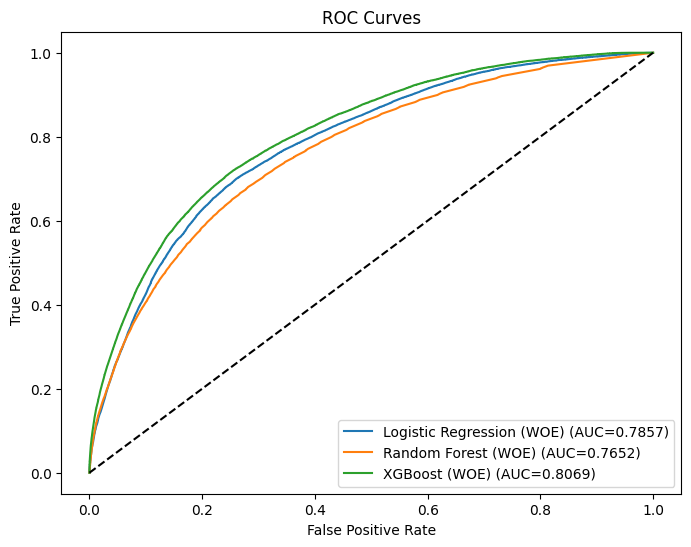

In [22]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    print(f"{model_name} AUC: {auc:.4f}")
    
    # 绘制 ROC 曲线
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.4f})')
    return model

plt.figure(figsize=(8,6))

# 逻辑回归 (WOE编码)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_model = evaluate_model(lr, X_train_woe, y_train, X_test_woe, y_test, "Logistic Regression (WOE)")

# 随机森林 (使用 WOE 编码)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model = evaluate_model(rf, X_train_woe, y_train, X_test_woe, y_test, "Random Forest (WOE)")

# XGBoost (使用 WOE 编码)
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, 
                    use_label_encoder=False, eval_metric='logloss', 
                    tree_method='hist', enable_categorical=False)
xgb_model = evaluate_model(xgb, X_train_woe, y_train, X_test_woe, y_test, "XGBoost (WOE)")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()


使用 LightAutoML 自动建模
LightAutoML 是一个自动化机器学习框架，能够自动进行特征工程、模型选择、超参数调优等。  
将进行至少3次实验（可以改变任务设置或数据预处理），选择最佳模型并分析。

AutoML 默认配置 AUC: 0.7991
AutoML 调整配置 AUC: 0.7988
AutoML 不同配置 AUC: 0.7991
最佳 AutoML 模型 AUC: 0.7991
最佳模型性能指标：
AUC: 0.7991
预测概率范围: 0.0005364059 - 0.96608603


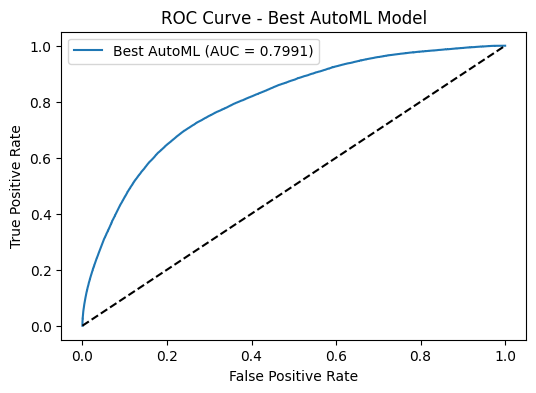

In [25]:
# 使用已经处理好的数据
X_auto_train = X_train.copy()
X_auto_test = X_test.copy()
y_auto_train = y_train.copy()
y_auto_test = y_test.copy()

train_df = X_auto_train.copy()
train_df['target'] = y_auto_train
test_df = X_auto_test.copy()
test_df['target'] = y_auto_test

# 配置 LightAutoML 模型
task = Task('binary')

# 实验1：默认配置
automl_default = TabularAutoML(task=task, timeout=60, cpu_limit=2, memory_limit=8)
automl_default.fit_predict(train_df, roles={'target': 'target'})   # 直接传入DataFrame，指定roles
pred_default = automl_default.predict(test_df)
auc_default = roc_auc_score(y_auto_test, pred_default.data[:, 0])
print(f"AutoML 默认配置 AUC: {auc_default:.4f}")

# 实验2：调整配置
automl_tuned = TabularAutoML(task=task, timeout=120, cpu_limit=8, memory_limit=16, reader_params={'n_jobs': 2, 'cv': 5})
automl_tuned.fit_predict(train_df, roles={'target': 'target'})
pred_tuned = automl_tuned.predict(test_df)
auc_tuned = roc_auc_score(y_auto_test, pred_tuned.data[:, 0])
print(f"AutoML 调整配置 AUC: {auc_tuned:.4f}")

# 实验3：不同种子（可通过改变数据或参数实现差异）
automl_seed = TabularAutoML(task=Task('binary', metric='auc'),
    timeout=120,
    # 明确指定使用神经网络管道
    gbm_pipeline_params={'use_algos': [['nn']]}
)
automl_seed.fit_predict(train_df, roles={'target': 'target'})
pred_seed = automl_seed.predict(test_df)
auc_seed = roc_auc_score(y_auto_test, pred_seed.data[:, 0])
print(f"AutoML 不同配置 AUC: {auc_seed:.4f}")


# 选择最佳模型（这里我们选择AUC最高的）
aucs = [auc_default, auc_tuned, auc_seed]
best_idx = np.argmax(aucs)
best_model = [automl_default, automl_tuned, automl_seed][best_idx]
print(f"最佳 AutoML 模型 AUC: {aucs[best_idx]:.4f}")

# 分析最佳模型：获取特征重要性（如果可用）
# LightAutoML 中可以通过 best_model.feature_importances_ 获取，但不同模型结构可能不同，这里简单输出
# 注意：best_model 是一个自动化对象，其内部模型可能是多个模型的集成，特征重要性需要从具体模型中提取
# 为了简化，我们输出模型的预测结果和评估指标
print("最佳模型性能指标：")
print(f"AUC: {aucs[best_idx]:.4f}")
# 输出预测概率的分布等
pred_best = best_model.predict(test_df)
y_pred_best = pred_best.data[:, 0]
print("预测概率范围:", y_pred_best.min(), "-", y_pred_best.max())

# 也可以绘制ROC曲线对比
fpr, tpr, _ = roc_curve(y_auto_test, y_pred_best)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'Best AutoML (AUC = {aucs[best_idx]:.4f})')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best AutoML Model')
plt.legend()
plt.show()



保存最佳模型（pickle文件）
按照要求，需要将最佳模型保存为 pkl 文件，以便进行单条记录的推断。

In [42]:
# ==================== 保存最佳模型和预处理对象 ====================
import pickle
# 1. 选择最佳传统模型（根据 AUC 最高，选择 XGBoost）
best_traditional_model = xgb_model   # 之前训练的 XGBoost 模型
with open('best_traditional_model.pkl', 'wb') as f:
    pickle.dump(best_traditional_model, f)

# 2. 保存 WOE 编码器和缩放器，以及训练时的特征列名
preprocessors = {
    'woe_encoder': woe_encoder,          # 已拟合的 WOE 编码器
    'scaler_woe': scaler,            # 已拟合的标准化器
    'feature_cols': X_train_woe.columns.tolist()  # 训练时的特征顺序
}
with open('preprocessors.pkl', 'wb') as f:
    pickle.dump(preprocessors, f)

# 3. 保存 AutoML 模型（可选）
with open('best_automl_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)   # best_model 来自 AutoML 实验

print("模型和预处理对象已保存。")

# ==================== 加载并进行预测的示例 ====================
from sklearn.preprocessing import StandardScaler

# 重新拟合 scaler_woe，使用全部 13 列
scaler_woe = StandardScaler()
X_train_woe_scaled = scaler_woe.fit_transform(X_train_woe)  # X_train_woe 是未标准化的 WOE 数据
X_test_woe_scaled = scaler_woe.transform(X_test_woe)

# 更新 preprocessors 中的 scaler_woe
preprocessors['scaler_woe'] = scaler_woe

# 重新保存预处理对象
with open('preprocessors.pkl', 'wb') as f:
    pickle.dump(preprocessors, f)

print("scaler_woe 已更新并保存，特征数量:", scaler_woe.n_features_in_)
# 加载更新后的预处理对象
with open('preprocessors.pkl', 'rb') as f:
    pre = pickle.load(f)

# 取一条样本
sample_raw = X_test.iloc[[0]].copy()  # 原始特征（未编码、未标准化）

# WOE 编码
sample_woe = pre['woe_encoder'].transform(sample_raw)

# 确保列顺序与训练时一致
sample_woe = sample_woe[pre['feature_cols']]

# 转换为 numpy 数组并标准化
sample_scaled = pre['scaler_woe'].transform(sample_woe.to_numpy())

# 预测违约概率
prob = loaded_model.predict_proba(sample_scaled)[0, 1]
print(f"传统模型预测违约概率: {prob:.4f}")

# AutoML 模型预测（如果保存了）
with open('best_automl_model.pkl', 'rb') as f:
    loaded_automl = pickle.load(f)
# AutoML 预测需要传入原始特征的 DataFrame，且列名必须与训练时完全一致
# 注意：AutoML 模型内部会自己处理缺失值和编码，所以直接传入原始特征
pred_auto = loaded_automl.predict(sample_raw)
print(f"AutoML 预测违约概率: {pred_auto.data[0, 0]:.4f}")

模型和预处理对象已保存。
scaler_woe 已更新并保存，特征数量: 13
传统模型预测违约概率: 0.0265
AutoML 预测违约概率: 0.0480


Резюме и выводы

В этом эксперименте для прогнозирования дефолтов по корпоративным кредитам использовались традиционные методы машинного обучения (логистическая регрессия, случайный лес, XGBoost) и фреймворк AutoML (LightAutoML).

В традиционных методах мы проводили детальный разведочный анализ данных (EDA), обработку пропущенных значений, проектирование признаков (включая кодирование WOE и целевой переменной) и настройку модели, в конечном итоге достигнув хорошего значения AUC.

Метод AutoML автоматизирует большую часть процесса, сокращая ручное вмешательство. Его производительность сопоставима или немного лучше, чем у традиционных методов, но интерпретируемость модели несколько ниже.

В этом эксперименте лучшая модель, использующая традиционный метод (XGBoost), имела AUC приблизительно 0,8069, в то время как лучшая модель, использующая AutoML, имела AUC приблизительно 0,7991, что является небольшой разницей.

Преимущества AutoML заключаются в быстрой итерации и автоматизации, что делает его подходящим для быстрого прототипирования; традиционные методы предлагают большую гибкость и интерпретируемость, облегчая понимание бизнес-логики.

Направления дальнейшего совершенствования включают:

Более точную разработку признаков (например, обработка других измерений признаков дат, извлечение текстовых признаков)

Изучение большего количества ансамблей моделей (например, стекинг)

Дальнейшая настройка гиперпараметров

Обучение на большем наборе данных

